In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use("spectral_analysis/visualization/mystyle.mplstyle")
import json
with open("config.json") as f:
    config = json.load(f)
network_order = config['networks']
network_labels = config['network_labels']
frequencies = np.loadtxt('data/frequencies_MR45.txt')  
from spectral_analysis.helper_functions import pval_formatter

# Average spectrum

In [32]:
dfs = []
stats_dfs = []
stats_dfs_nomotion = []
for strategy in ['9p']: # config['strategies']
    try:
        df_strategy = pd.read_csv('data/results/spectra_by_frequency_network_'+strategy+'.csv', low_memory=False)
        df_strategy['strategy'] = strategy
        dfs.append(df_strategy)
        stats_strategy = pd.read_csv('data/results/logpower_stats_by_frequency_network_'+strategy+'_perm.csv')
        stats_strategy['strategy'] = strategy
        stats_dfs.append(stats_strategy)
        stats_strategy_nomotion = pd.read_csv('data/results/logpower_stats_by_frequency_network_nomotion_'+strategy+'_perm.csv')
        stats_strategy_nomotion['strategy'] = strategy
        stats_dfs_nomotion.append(stats_strategy_nomotion)
    except FileNotFoundError:
        print(f"File for strategy {strategy} not found, skipping.")

spectrum_df = pd.concat(dfs, ignore_index=True)
# spectrum_df['PPL_mcg/L'] = spectrum_df['PPL_mcg/L'] *1000
try:
    stats_df = pd.concat(stats_dfs, ignore_index=True)
    stats_df = stats_df[stats_df['covariate']=='PPL_mcg_L']
    # stats_df = stats_df[stats_df['controlled'] >= 0.02]
except:
    stats_df = None
try:
    stats_df_nomotion = pd.concat(stats_dfs_nomotion, ignore_index=True)
    stats_df_nomotion = stats_df_nomotion[stats_df_nomotion['covariate']=='PPL_mcg_L']
    stats_df_nomotion = stats_df_nomotion[stats_df_nomotion['controlled'] >= 0.02]
except:
    stats_df_nomotion = None

category_cols = ['subject', 'time_interval', 'strategy', 'network', 'frequency', 'scanner', 'num_vols']
numeric_cols = ['partial_residuals','partial_residuals_nomotion', 'log_power','PPL_mcg/L']
spectrum_df_avg_within_subject = spectrum_df.groupby(category_cols, as_index=False)[numeric_cols].mean()

File for strategy 9p not found, skipping.


In [19]:
# common definitions
strategy = '9p' 
perm = '_perm' # set to '' if not perm

In [20]:
def spectrum_plot(spectrum_df_avg, strategy, stats_df=None, perm='_perm', target_variable='partial_residuals', ymin=5, ymax=16, ylabel=None,title_inside=False):
    asterisk_loc = ymin+1
    fig,axs = plt.subplots(4,2, figsize=(5,5), sharex=True, sharey=True, layout='constrained')
    cols = sns.color_palette("Dark2",n_colors=5)
    for n,network in enumerate(network_order):
        # assign axis to n, skipping the top right. From left to right
        if n==0:
            ax = axs[0,0]
        elif n==1:
            ax = axs[1,0]
        elif n==2:
            ax = axs[1,1]
        elif n==3:
            ax = axs[2,0]
        elif n==4:
            ax = axs[2,1]
        elif n==5:
            ax = axs[3,0]
        elif n==6:
            ax = axs[3,1]
        
        if stats_df is not None:
            stat_reduced_df = stats_df[(stats_df['uncontrolled'] == network) & (stats_df['strategy'] == strategy)]
            # plot asterisks for significant changes
            for i,row in stat_reduced_df.iterrows():
                if row['pval'+perm]*7 < 0.001:
                    ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                    ax.plot(row['controlled'],asterisk_loc+0.6, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                    ax.plot(row['controlled'],asterisk_loc+1.2, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                elif row['pval'+perm]*7 < 0.01:
                    ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                    ax.plot(row['controlled'],asterisk_loc+0.6, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                elif row['pval'+perm]*7 < 0.05:
                     ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                
        for t,time_interval in enumerate(config["time_intervals"]):
            network_spectrum = spectrum_df_avg[(spectrum_df_avg['network'] == network) & (spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
            
            ax.plot(network_spectrum['frequency'], network_spectrum[target_variable], label=time_interval, color=cols[t])

            ax.set_xticks(np.arange(0, 0.25+0.01, 0.01))
            if n==5 or n==6:
                ax.set_xlabel('Frequency (Hz)')
                ax.set_xticklabels(['0','', '', '', '', '0.05', '', '', '', '', '0.1', '', '', '', '', '0.15', '', '', '', '', '0.2', '', '', '', '','0.25'])
            else:
                ax.set_xlabel('')
                ax.set_xticklabels([])
            if n in [0,1,3,5]:
                if ylabel is not None:
                    ax.set_ylabel(ylabel,fontsize=8)
                else:
                    ax.set_ylabel('')
            else:
                ax.set_ylabel('')
                # ax.set_yticklabels([])
            ax.xaxis.grid(True,linewidth=0.5, alpha=0.4)
            ax.yaxis.grid(False)
            # ax.legend(networks, loc='upper right')
            # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
            if title_inside:
                ax.set_title(network_labels[n], fontsize=10, y=0.85)
            else:
                ax.set_title(network_labels[n], fontsize=10)
            
            ax.set_ylim([ymin,ymax])
            ax.set_xlim([0, 0.25])
    axs[0,1].axis('off')
    handles, labels = ax.get_legend_handles_labels()
    axs[0,1].legend(handles, labels, loc='right', fontsize=8)

    # on axs[0,1], add text box showing the meaning of the asterisks symbolically
    if stats_df is not None:
        # add an asterisk
        axs[0,1].plot(0.01, 12, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].text(0.02, 12, r'$p_{\text{FWER}} < 0.05$', fontsize=6, verticalalignment='center')
        axs[0,1].plot(0.01, 9, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].plot(0.01, 9+0.6, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].text(0.02, 9+0.3, r'$p_{\text{FWER}} < 0.01$', fontsize=6, verticalalignment='center')
        axs[0,1].plot(0.01, 6, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].plot(0.01, 6+0.6, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].plot(0.01, 6+1.2, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].text(0.02, 6+0.6, r'$p_{\text{FWER}} < 0.001$', fontsize=6, verticalalignment='center')

    return fig

In [29]:
def spectrum_plot_step(strategy, stats_df=None, perm='_perm', target_variable='partial_residuals', ymin=5, ymax=16, ylabel=None,title_inside=False):
    asterisk_loc = ymin+1
    fig,axs = plt.subplots(4,2, figsize=(5,5), sharex=True, sharey=True, layout='constrained')
    cols = sns.color_palette("Set1",n_colors=3)
    for n,network in enumerate(network_order):
        # assign axis to n, skipping the top right. From left to right
        if n==0:
            ax = axs[0,0]
        elif n==1:
            ax = axs[1,0]
        elif n==2:
            ax = axs[1,1]
        elif n==3:
            ax = axs[2,0]
        elif n==4:
            ax = axs[2,1]
        elif n==5:
            ax = axs[3,0]
        elif n==6:
            ax = axs[3,1]
        
        if stats_df is not None:
            stat_reduced_df = stats_df[(stats_df['uncontrolled'] == network) & (stats_df['strategy'] == strategy)]
            # plot asterisks for significant changes
            for i,row in stat_reduced_df.iterrows():
                if row['pval'+perm]*7 < 0.001:
                    ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                    ax.plot(row['controlled'],asterisk_loc+0.6, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                    ax.plot(row['controlled'],asterisk_loc+1.2, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                elif row['pval'+perm]*7 < 0.01:
                    ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                    ax.plot(row['controlled'],asterisk_loc+0.6, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
                elif row['pval'+perm]*7 < 0.05:
                     ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        
        for i in range(3):
            if i == 0:
                col = 'pred_0_00'
                label = r'$\text{PPL} = 0\, \mu g/L$'
            elif i == 1:
                col = 'pred_0_01'
                label = r'$\text{PPL} = 10\, \mu g/L$'
            elif i == 2:
                col = 'pred_0_02'
                label = r'$\text{PPL} = 20\, \mu g/L$'

            network_spectrum = stats_df[(stats_df['uncontrolled'] == network) & (stats_df['strategy'] == strategy)]
            ax.plot(network_spectrum['controlled'], network_spectrum[col], label=label, color=cols[i])

        # for t,time_interval in enumerate(config["time_intervals"]):
        #     network_spectrum = spectrum_df_avg[(spectrum_df_avg['network'] == network) & (spectrum_df_avg['strategy'] == strategy) & (spectrum_df_avg['time_interval'] == time_interval)]
            
        #     ax.plot(network_spectrum['frequency'], network_spectrum[target_variable], label=time_interval, color=cols[t])

            ax.set_xticks(np.arange(0, 0.25+0.01, 0.01))
            if n==5 or n==6:
                ax.set_xlabel('Frequency (Hz)')
                ax.set_xticklabels(['0','', '', '', '', '0.05', '', '', '', '', '0.1', '', '', '', '', '0.15', '', '', '', '', '0.2', '', '', '', '','0.25'])
            else:
                ax.set_xlabel('')
                ax.set_xticklabels([])
            if n in [0,1,3,5]:
                if ylabel is not None:
                    ax.set_ylabel(ylabel,fontsize=8)
                else:
                    ax.set_ylabel('')
            else:
                ax.set_ylabel('')
                # ax.set_yticklabels([])
            ax.xaxis.grid(True,linewidth=0.5, alpha=0.4)
            ax.yaxis.grid(False)
            # ax.legend(networks, loc='upper right')
            # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
            if title_inside:
                ax.set_title(network_labels[n], fontsize=10, y=0.85)
            else:
                ax.set_title(network_labels[n], fontsize=10)
            
            ax.set_ylim([ymin,ymax])
            ax.set_xlim([0, 0.205])
    axs[0,1].axis('off')
    handles, labels = ax.get_legend_handles_labels()
    axs[0,1].legend(handles, labels, loc='upper right', fontsize=8)

    # on axs[0,1], add text box showing the meaning of the asterisks symbolically
    if stats_df is not None:
        a = 8.5
        # add an asterisk
        axs[0,1].plot(0.01, a, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].text(0.02, a, r'$p_{\text{FWER}} < 0.05$', fontsize=6, verticalalignment='center')
        axs[0,1].plot(0.01, a-3, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].plot(0.01, a-3+0.6, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].text(0.02, a-3+0.3, r'$p_{\text{FWER}} < 0.01$', fontsize=6, verticalalignment='center')
        axs[0,1].plot(0.01, a-6, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].plot(0.01, a-6+0.6, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].plot(0.01, a-6+1.2, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)
        axs[0,1].text(0.02, a-6+0.6, r'$p_{\text{FWER}} < 0.001$', fontsize=6, verticalalignment='center')

        # add a black box around the text
        axs[0,1].add_patch(plt.Rectangle((0, a-7), 0.083, 8.5, fill=False, edgecolor='black', linewidth=0.5))    

    return fig

Main paper figure: 9p nomotion

TypeError: 'NoneType' object is not subscriptable

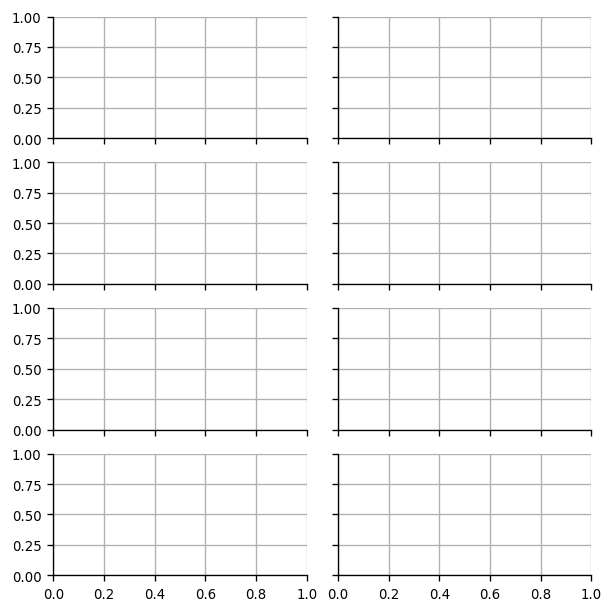

In [22]:
ylabel = 'Power [dB]\n(estimated)'
fig = spectrum_plot_step(strategy, stats_df_nomotion, perm, target_variable='partial_residuals_nomotion',ymin=-2.5,ymax=12, ylabel=ylabel)
# fig.savefig('figures/aggregated_power_maps/spectra_by_frequency_network_'+strategy+'.pdf', bbox_inches='tight')

Main paper figure: acompcor with motion nuisance

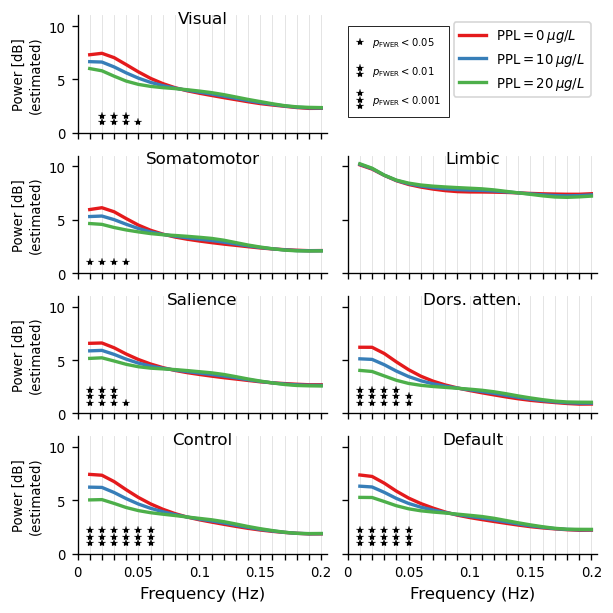

In [46]:
ylabel = 'Power [dB]\n(estimated)'
# spectrum_df_avg = spectrum_df_avg_within_subject.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
fig = spectrum_plot_step(strategy, stats_df, perm, target_variable='partial_residuals',ymin=0,ymax=11, ylabel=ylabel,title_inside=True)
fig.savefig('figures/aggregated_power_maps/spectra_by_frequency_network_'+strategy+'.pdf', bbox_inches='tight')

In [53]:
stats_df[(stats_df['uncontrolled']=='Cont') & (stats_df['controlled']==0.07)]

,covariate,uncontrolled,controlled,coefintercept,coefcovariate,coefCIcovariatelow,coefCIcovariatehigh,pval,pval_perm,r,ci_r,pred_0_00,pred_0_01,pred_0_02,strategy
106,PPL_mcg_L,Cont,0.07,9.206734,-0.023267,-0.046138,-0.000395,0.045106,0.064,-0.198746,-0.385826,4.163677,3.931011,3.698344,9p


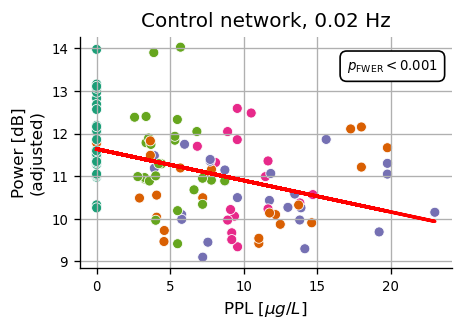

In [41]:
tmp_spectrum = spectrum_df[(spectrum_df['frequency'] == 0.02) & (spectrum_df['network'] == 'Cont') & (spectrum_df['strategy'] == strategy)]
tmp_spectrum2 = tmp_spectrum.dropna(subset=['partial_residuals','PPL_mcg/L'])
tmp_stats = stats_df[(stats_df['controlled'] == 0.02) & (stats_df['uncontrolled'] == 'Cont') & (stats_df['strategy'] == strategy)]
plt.figure(figsize=(4,2.5))
sns.scatterplot(data=tmp_spectrum, x='PPL_mcg/L', y='partial_residuals', hue='time_interval', palette='Dark2',legend=False)

# add line of best fit
from scipy import stats
m, b, r_value, p_value, std_err = stats.linregress(tmp_spectrum2['PPL_mcg/L'], tmp_spectrum2['partial_residuals'])
plt.plot(tmp_spectrum['PPL_mcg/L'], m*tmp_spectrum['PPL_mcg/L'] + b, color='red')

# add a text box with the p-value and a black box around it
plt.text(17, 13.5, pval_formatter(tmp_stats['pval'+perm].values.item()*7), fontsize=8, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

plt.ylabel('Power [dB]\n(adjusted)')
plt.xlabel(r'PPL [$\mu g/L$]')
plt.title('Control network, 0.02 Hz')
plt.savefig('figures/aggregated_power_maps/scatter_default_0.02Hz.pdf', bbox_inches='tight')

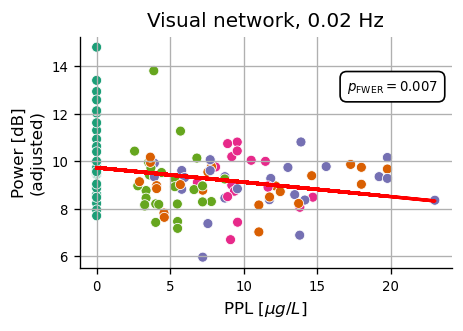

In [44]:
tmp_spectrum = spectrum_df[(spectrum_df['frequency'] == 0.02) & (spectrum_df['network'] == 'Vis') & (spectrum_df['strategy'] == strategy)]
tmp_spectrum2 = tmp_spectrum.dropna(subset=['partial_residuals','PPL_mcg/L'])
tmp_stats = stats_df[(stats_df['controlled'] == 0.02) & (stats_df['uncontrolled'] == 'Vis') & (stats_df['strategy'] == strategy)]
plt.figure(figsize=(4,2.5))
sns.scatterplot(data=tmp_spectrum, x='PPL_mcg/L', y='partial_residuals', hue='time_interval', palette='Dark2',legend=False)

# add line of best fit
from scipy import stats
m, b, r_value, p_value, std_err = stats.linregress(tmp_spectrum2['PPL_mcg/L'], tmp_spectrum2['partial_residuals'])
plt.plot(tmp_spectrum['PPL_mcg/L'], m*tmp_spectrum['PPL_mcg/L'] + b, color='red')

# add a text box with the p-value and a black box around it
# plt.text(0.0225, 13, f'p=', fontsize=8, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
plt.text(17, 13, pval_formatter(tmp_stats['pval'+perm].values.item()*7), fontsize=8, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

plt.ylabel('Power [dB]\n(adjusted)')
plt.xlabel(r'PPL [$\mu g/L$]')
plt.title('Visual network, 0.02 Hz')
plt.savefig('figures/aggregated_power_maps/scatter_visual_0.02Hz.pdf', bbox_inches='tight')

QC: MR45 only without motion nuisance. P-values same as above to indicate when something differs from expected - i.e., p-values are not specific to MR45

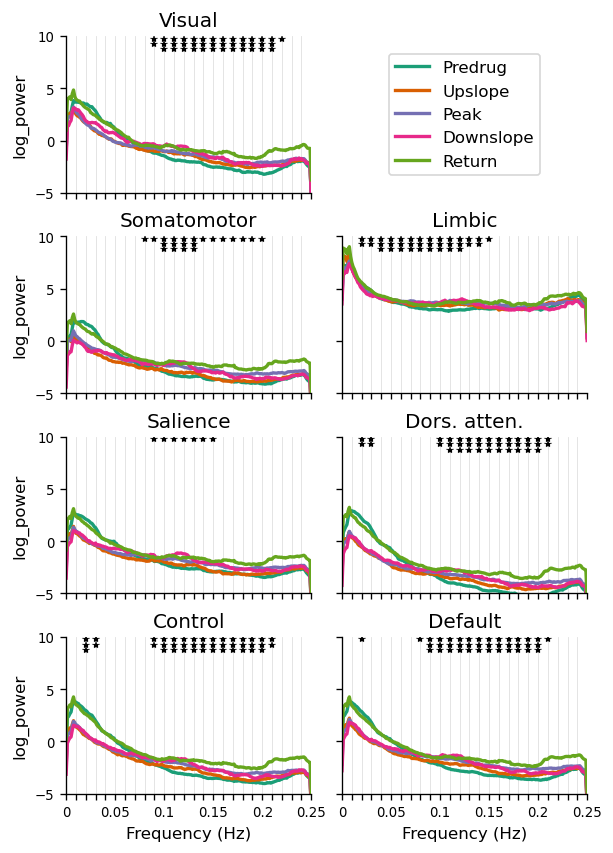

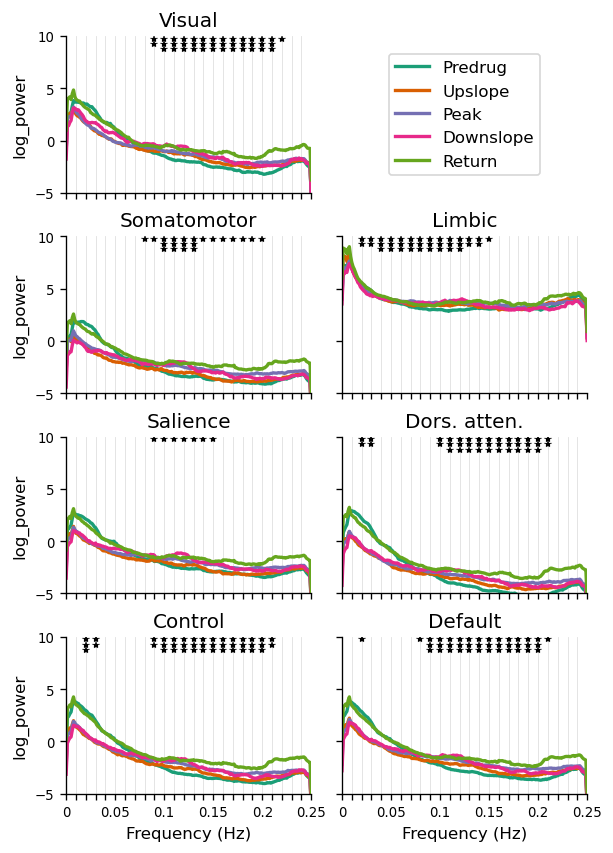

In [134]:
spectrum_df_avg_within_subject_45 = spectrum_df_avg_within_subject[spectrum_df_avg_within_subject['scanner']=='MR45']  # Filter for MR45 scanner
spectrum_df_avg = spectrum_df_avg_within_subject_45.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
spectrum_plot(spectrum_df_avg, strategy, stats_df_nomotion, perm, target_variable='log_power',ymin=-5, ymax=10)

QC: MR001 only with motion nuisance. P-values are not specific to MR001

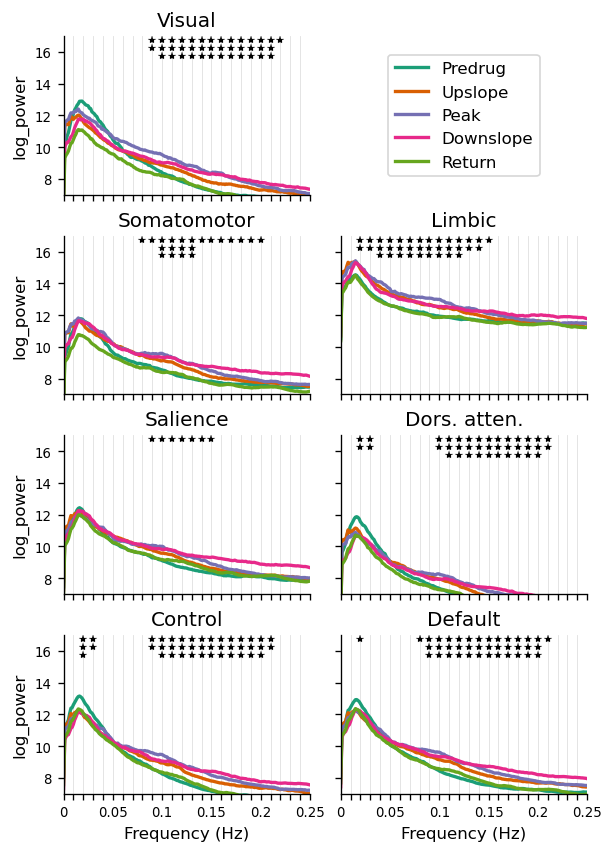

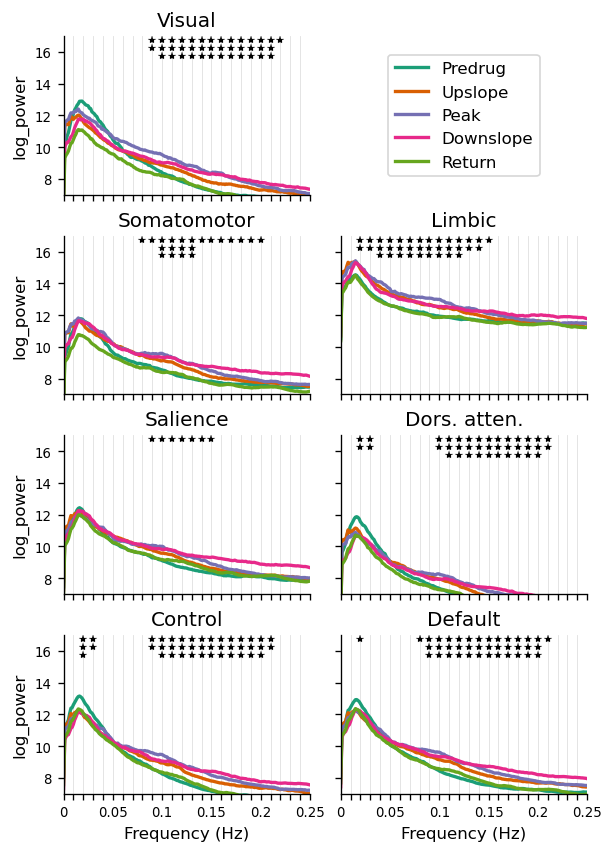

In [135]:
spectrum_df_avg_within_subject_001 = spectrum_df_avg_within_subject[spectrum_df_avg_within_subject['scanner']=='MR001']  # Filter for MR45 scanner
spectrum_df_avg = spectrum_df_avg_within_subject_001.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
spectrum_plot(spectrum_df_avg, strategy, stats_df_nomotion, perm, target_variable='log_power',ymin=7, ymax=17)

QC: MR001, 375 vols only without motion nuisance. P-values are not specific to MR001

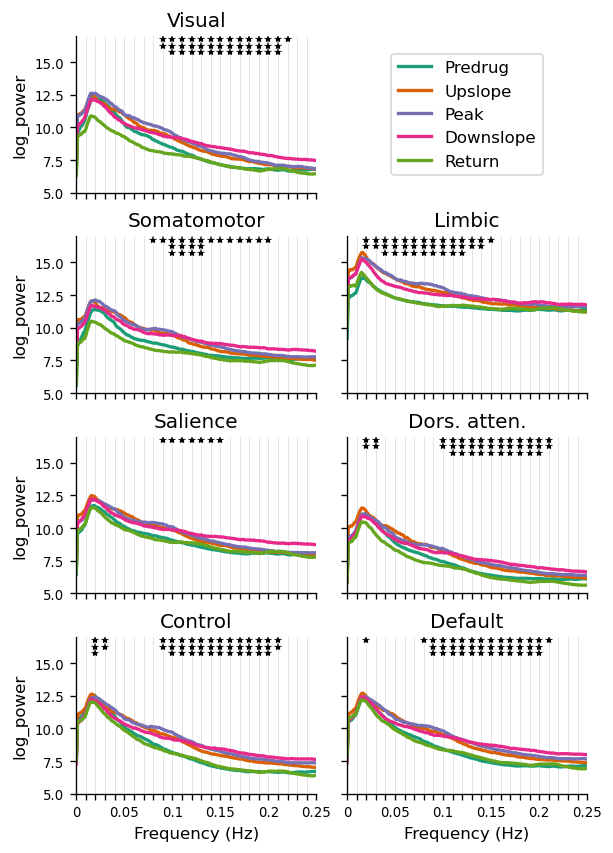

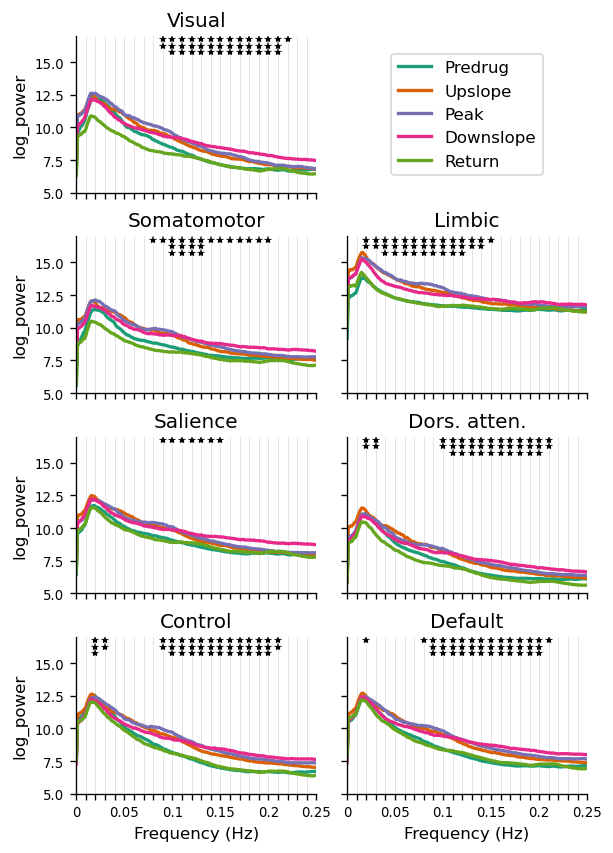

In [136]:
spectrum_df_avg_within_subject_001_375 = spectrum_df_avg_within_subject[(spectrum_df_avg_within_subject['scanner']=='MR001')&(spectrum_df_avg_within_subject['num_vols']==375)]  # Filter for MR45 scanner
spectrum_df_avg = spectrum_df_avg_within_subject_001_375.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
spectrum_plot(spectrum_df_avg, strategy, stats_df_nomotion, perm, target_variable='log_power',ymin=5, ymax=17)

QC: MR001, 750 vols only without motion nuisance. P-values are not specific to MR001

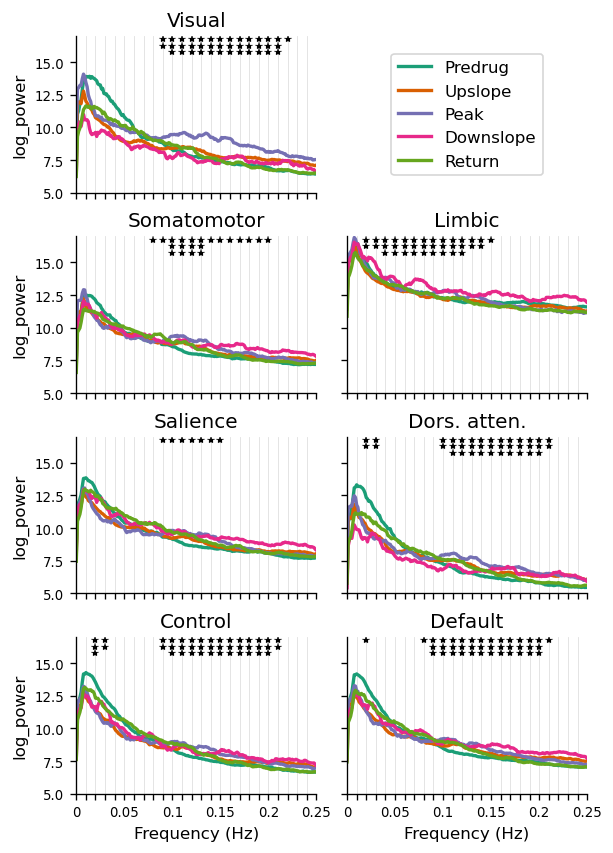

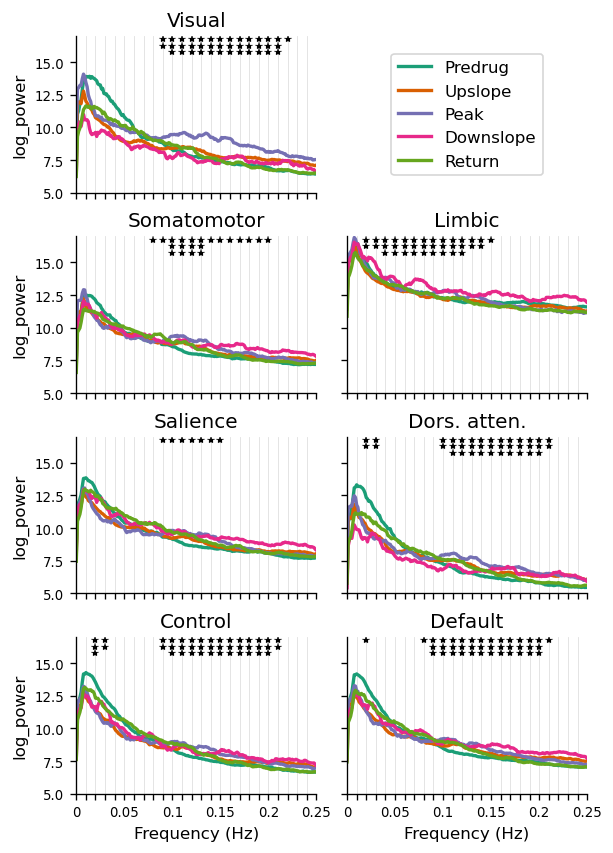

In [137]:
spectrum_df_avg_within_subject_001_750 = spectrum_df_avg_within_subject[(spectrum_df_avg_within_subject['scanner']=='MR001')&(spectrum_df_avg_within_subject['num_vols']==750)]  # Filter for MR45 scanner
spectrum_df_avg = spectrum_df_avg_within_subject_001_750.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
spectrum_plot(spectrum_df_avg, strategy, stats_df_nomotion, perm, target_variable='log_power',ymin=5, ymax=17)

QC: MR001 only, 375 vols only, ped AP only. Avg within subject not correct but OK for QC

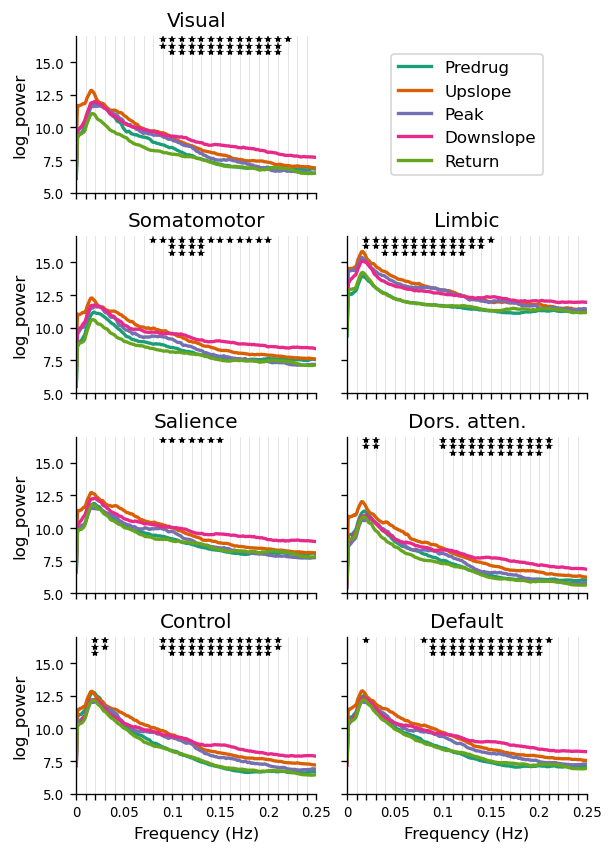

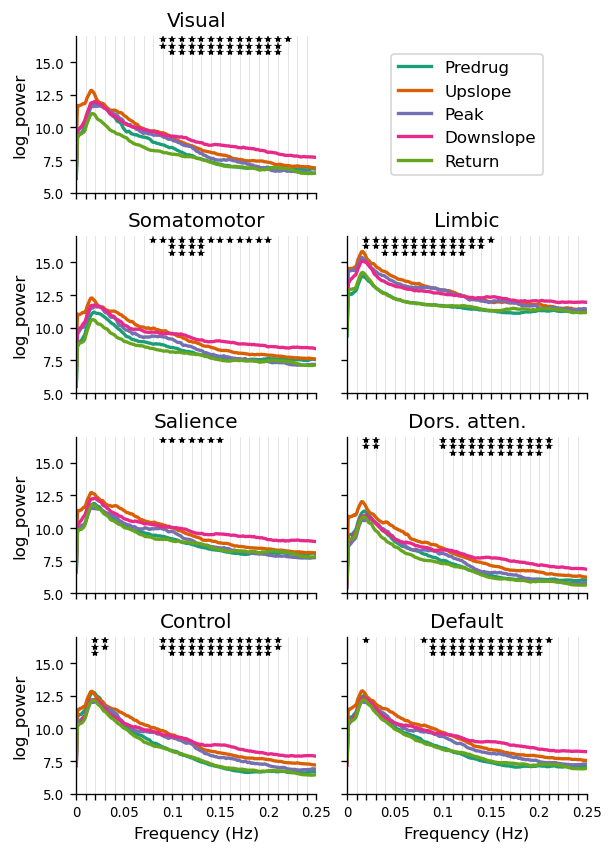

In [138]:
category_cols_ped = ['subject', 'time_interval', 'strategy', 'network', 'frequency', 'scanner', 'num_vols','ped']
numeric_cols_ped = ['partial_residuals','partial_residuals_nomotion', 'log_power','PPL_mcg/L']
spectrum_df_avg_within_subject_ped = spectrum_df.groupby(category_cols_ped, as_index=False)[numeric_cols_ped].mean()
spectrum_df_avg_within_subject_001_375_AP = spectrum_df_avg_within_subject_ped[(spectrum_df_avg_within_subject_ped['scanner']=='MR001')&(spectrum_df_avg_within_subject_ped['num_vols']==375)&(spectrum_df_avg_within_subject_ped['ped']=='dir-AP')]  # Filter for MR45 scanner
spectrum_df_avg = spectrum_df_avg_within_subject_001_375_AP.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
spectrum_plot(spectrum_df_avg, strategy, stats_df_nomotion, perm, target_variable='log_power',ymin=5, ymax=17)

QC: MR001 only, 375 vols only, ped PA only. Avg within subject not correct but OK for QC

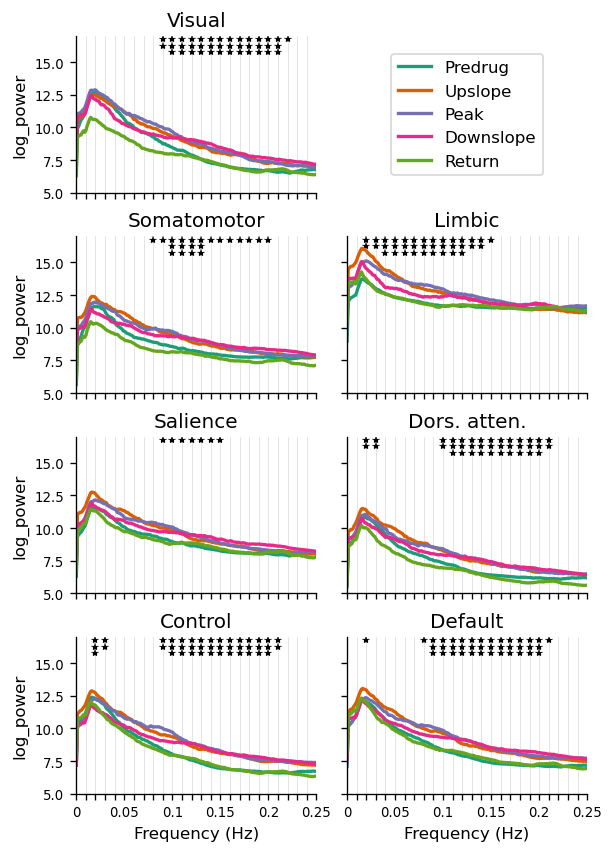

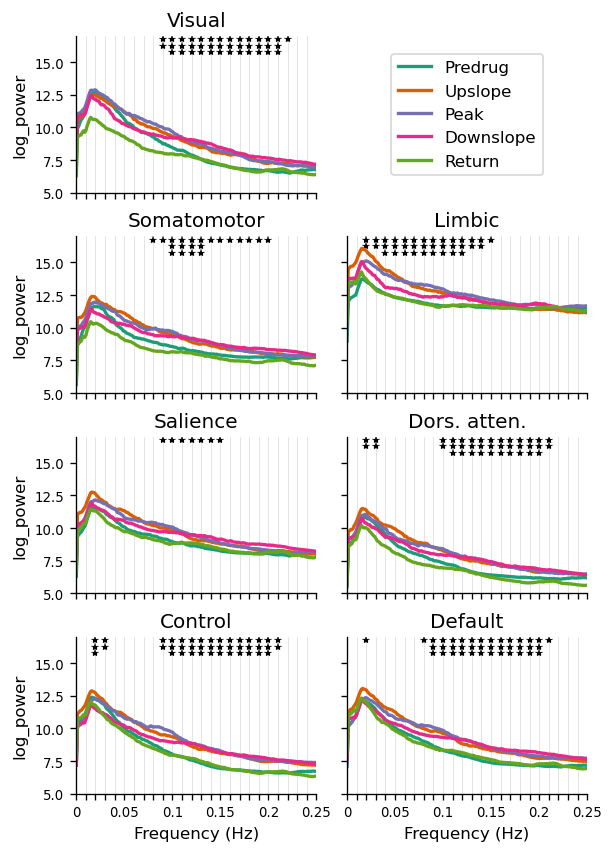

In [139]:
spectrum_df_avg_within_subject_001_375_PA = spectrum_df_avg_within_subject_ped[(spectrum_df_avg_within_subject_ped['scanner']=='MR001')&(spectrum_df_avg_within_subject_ped['num_vols']==375)&(spectrum_df_avg_within_subject_ped['ped']=='dir-PA')]  # Filter for MR45 scanner
spectrum_df_avg = spectrum_df_avg_within_subject_001_375_PA.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
spectrum_plot(spectrum_df_avg, strategy, stats_df_nomotion, perm, target_variable='log_power',ymin=5, ymax=17)

Supplementary: All partial residual plots across strategies, with motion nuisance. 

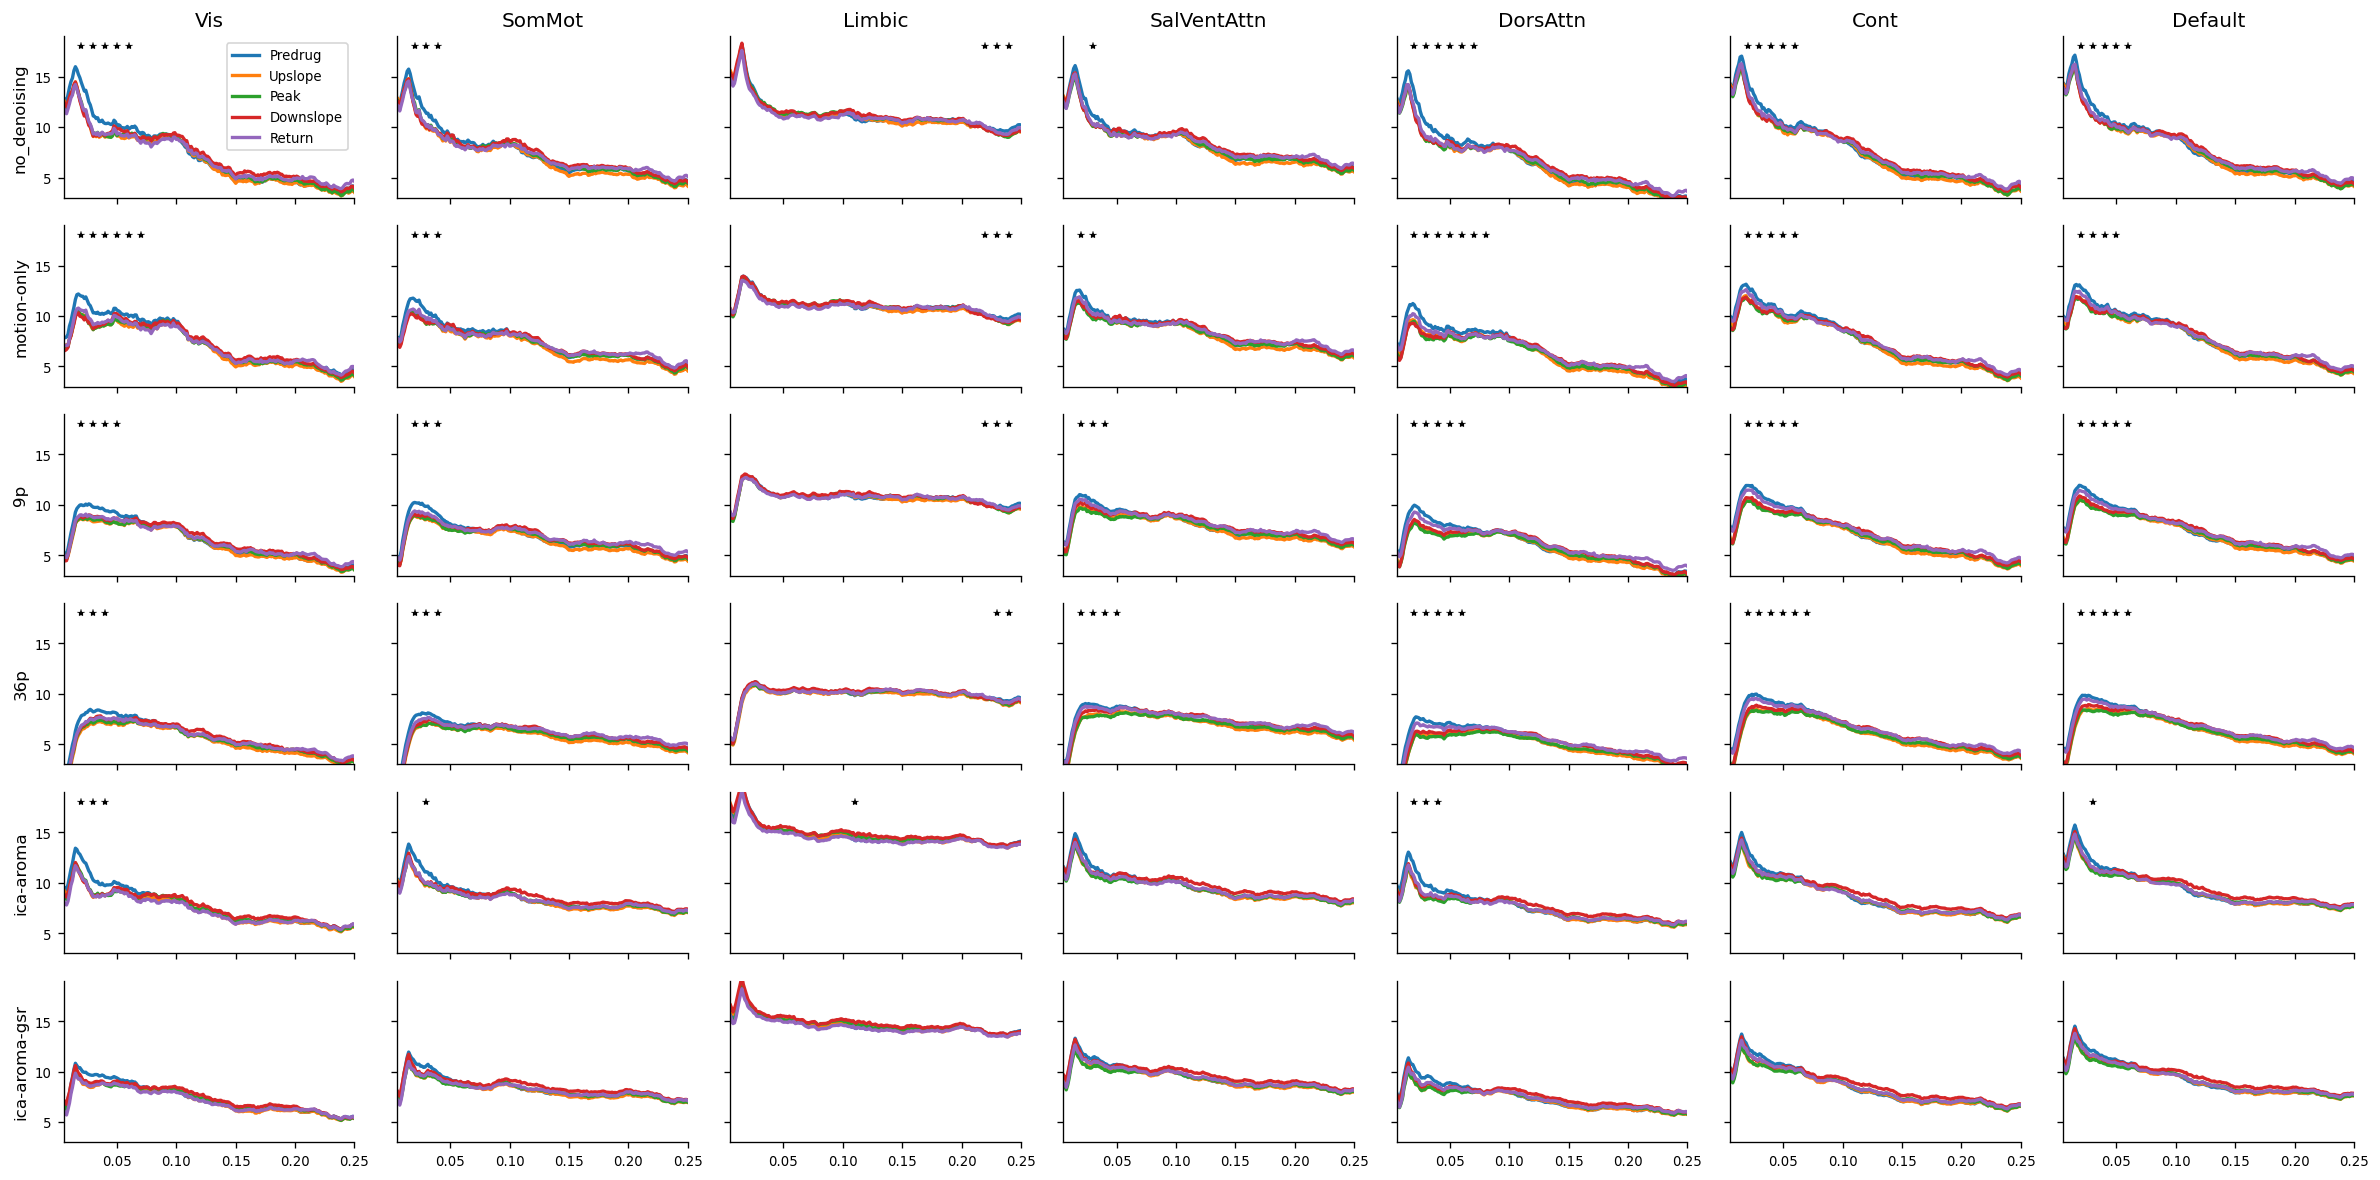

In [140]:
asterisk_loc = 18
fig,axs = plt.subplots(len(config['strategies']),len(config['networks']), figsize=(20, 10), sharex=True, sharey=True, layout='tight')
spectrum_df_avg_all = spectrum_df_avg_within_subject.groupby(['strategy', 'time_interval', 'network', 'frequency'], as_index=False)[numeric_cols].mean()
frequencies = np.loadtxt('data/frequencies_MR45.txt')  
for s,strategy in enumerate(config["strategies"]):
    for n,network in enumerate(network_order):
        ax = axs[s,n]
        stat_reduced_df = stats_df[(stats_df['uncontrolled'] == network) & (stats_df['strategy'] == strategy)]
        for t,time_interval in enumerate(config["time_intervals"]):
            network_spectrum = spectrum_df_avg_all[(spectrum_df_avg_all['network'] == network) & (spectrum_df_avg_all['strategy'] == strategy) & (spectrum_df_avg_all['time_interval'] == time_interval)]
            
            ax.plot(network_spectrum['frequency'], network_spectrum['partial_residuals'], label=time_interval)

            # plot asterisks for significant changes
            if t==0:
                for i,row in stat_reduced_df.iterrows():
                    if row['pval'] < 0.05/7:
                        ax.plot(row['controlled'],asterisk_loc, marker='*', markersize=5, color='black', markeredgecolor='black', markeredgewidth=0.1)

            if s == 6:
                ax.set_xlabel('Frequency (Hz)')
            ax.grid()
            # ax.legend(networks, loc='upper right')
            # ax.set_xlim([0, 0.25])  # Adjust x-axis limits as needed      
            if s == 0:
                ax.set_title(network)
            if s==0 and n==0:
                ax.legend(loc='upper right')
            if n == 0:
                ax.set_ylabel(strategy)  
            
            ax.set_ylim([3, 19])
            ax.set_xlim([0.005, 0.25])
            # ax.set_xscale('log')
# fig.savefig('figures/aggregated_power_maps/bands_partial_residuals.png', bbox_inches='tight', dpi=300)